### K-nearest neighbors

[Video](https://youtu.be/qJnFWgFESZQ)

Der k-Nearest Neighbors (k-NN) Algorithmus ist einer der einfachsten und intuitivsten Machine Learning Algorithmen. 

Die Grundidee ist: "Sage mir, wer deine Nachbarn sind, und ich sage dir, wer du bist!"

Der Algorithmus klassifiziert einen neuen Datenpunkt basierend auf den k nächstgelegenen bekannten Datenpunkten.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

**Beispiel 1:** Interesse an Bioinformatik in Abhängigkeit davon, wieviele Informatik und Biovorlesungen belegt wurden.

Wir haben 10 Datenpunkte und jeder Datenpunkt hat 2 Features - die Anzahl gehörter Informatikvorlesungen sowie die Anzahl gehörter Biologievorlesungen. Dann haben wir noch ein binäres Label, welches angibt, ob eine Person Interesse an der Bioinformatik hat oder nicht.

In [ ]:
df = pd.DataFrame({'inf':[0, 0, 2, 3, 4, 4, 4, 5, 6, 7],
                   'bio':[0, 1, 1, 2, 2, 4, 5, 5, 6, 6],
                   'bioinf':[0, 0, 0, 0, 0, 1, 1, 1, 1, 1]})
df

In [ ]:
sns.scatterplot(x='inf',y='bio',hue='bioinf',data=df,s=50);

In [ ]:
X = df.drop('bioinf',axis=1)
y = df['bioinf']

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X, y);

In [ ]:
X_test = pd.DataFrame([(3,3),(1,1),(5,4),(3,5)],columns=['inf','bio'])
knn.predict(X_test)

In [ ]:
farben_map = {0: "blue", 1: "red"}
farben = [farben_map[x] for x in knn.predict(X_test)]
sns.scatterplot(x='inf', y='bio', hue='bioinf', data=df, s=50)
# Predictions
plt.scatter(x= X_test['inf'],y=X_test['bio'], c=farben, s=50, marker='X')
plt.show()


**Beispiel 2:** Gen-Expressions  

Gene Expression Levels beschreiben, wie aktiv ein Gen in einer Zelle ist – also wie viel des Produkts eines Gens (meist ein Protein oder eine RNA) hergestellt wird.

Ein Gen ist ein Abschnitt der DNA, der eine Bauanleitung für ein Protein enthält.
Aber nicht alle Gene sind immer „eingeschaltet“. Die Genexpression ist der Prozess, bei dem die Information eines Gens abgelesen und in ein Produkt umgewandelt wird.

Die Daten zeigen das Vorhandensein von Krebs in Abhängigkeit von den Gen Expression Levels zweier Gene.

In [181]:
df = pd.read_csv('gene_expression.csv')
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


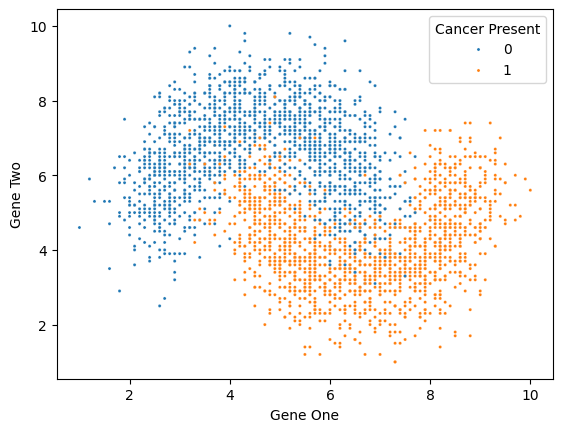

In [182]:
sns.scatterplot(x='Gene One',y='Gene Two',hue='Cancer Present',data=df,s=5);

In [183]:
X = df.drop('Cancer Present',axis=1)
y = df['Cancer Present']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [192]:
knn = KNeighborsClassifier(n_neighbors = 7)
knn.fit(X_train, y_train);

In [193]:
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
acc

0.9306666666666666

----

**Beispiel 3:** Das Beispiel zeigt, dass manchmal eine Skalierung sinnvoll ist (tatsächlich wird fast immer skaliert).

Der rote Stern liegt optisch näher an den blauen Punkten, wird aber trotzdem als gelb klassifiziert, da die Werte von f1 sehr groß gegenüber f2 sind.

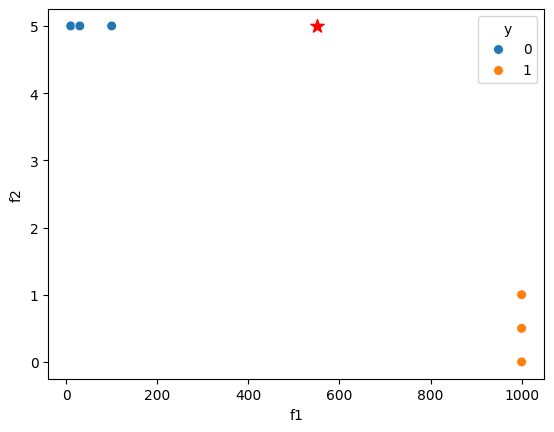

In [195]:
X = np.array([
    [10, 5],   
    [30, 5],    
    [100,5],
    [1000, 1],    
    [1000, 0.5],   
    [1000, 0]     
])

y = [0, 0, 0, 1, 1, 1] 
df = pd.DataFrame(X,columns=['f1','f2'])
df['y']=y
 
sns.scatterplot(x='f1',y='f2',hue='y',data=df,s=50);
plt.scatter(550, 5, color='red', marker='*', s=100)
plt.show()

In [196]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X, y);
knn.predict([(550,5)])

array([1])

In [197]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
scaler.transform([[550,5]])

array([[0.05585263, 0.99186978]])

Nach der Skalierung wird der rote Stern den blauen Punkten zugeordnet.

In [198]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X, y);
knn.predict([(0.05585263, 0.99186978)])

array([0])

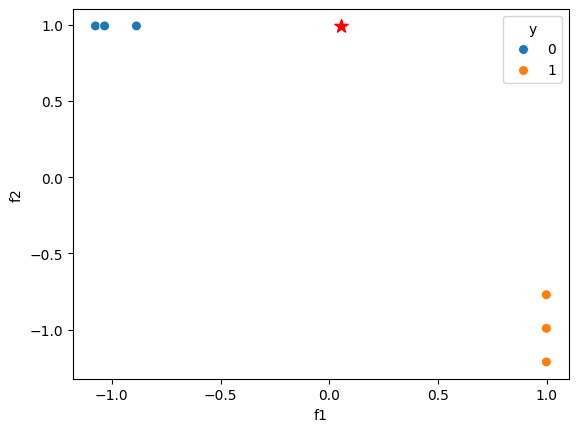

In [199]:
df = pd.DataFrame(X,columns=['f1','f2'])
df['y']=y
sns.scatterplot(x='f1',y='f2',hue='y',data=df,s=50);
plt.scatter(0.05585263, 0.99186978, color='red', marker='*', s=100)
plt.show()